In [1]:
import os
import sys
import tqdm
import json
project_dir = os.path.dirname(os.getcwd())
sys.path.append(project_dir)

from utils.summary import get_model_stats
from utils.plots import plot_training_metrics
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet34

import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


# Data

In [2]:
from data.voc import get_voc_pipeline_test

train_loader, val_loader, test_loader = get_voc_pipeline_test(batch_size=16)
sample_x, sample_y = next(iter(train_loader))
print(sample_x.shape)
print(sample_y.shape)   # oh so it squeezes it for me... interesting change...

Using downloaded and verified file: /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar
Extracting /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar to /home/dodogama/code/project_compression/data
Using downloaded and verified file: /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar
Extracting /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar to /home/dodogama/code/project_compression/data
torch.Size([16, 3, 256, 256])
torch.Size([16, 256, 256])


# Model Stats

# Teacher

In [ ]:
from utils.losses import MIoU
from utils.train import train_model

def train_model(train_loader: DataLoader, model: nn.Module, criterion: nn.Module, optimizer: nn.Module,
                scheduler: nn.Module=None, device: str='cpu') -> list:
    """
    Train the model for one epoch.

    Args:
        model: The PyTorch model to train.
        train_loader: DataLoader for the training data.
        optimizer: Optimizer for updating model parameters.
        criterion: Loss function.
        device: Device to run the training on ('cpu' or 'cuda').

    Returns:
        list: Collection of train losses.
    """
    model.train()
    epoch_losses = []
    for inputs, targets in tqdm.tqdm(train_loader, desc='training...', file=sys.stdout):
        inputs = inputs.to(device)
        # targets = targets.squeeze(1).long().to(device)
        targets = targets.to(device)
        preds = model(inputs)
        loss = criterion(preds, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
        if scheduler and isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(loss.item())
    if scheduler and not isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step()
    return epoch_losses


def evaluate_model(val_loader: DataLoader, model: nn.Module, criterion: nn.Module, device: str='cpu') -> list:
    """
    Evaluate the model on validation data.

    Args:
        model: The PyTorch model to evaluate.
        val_loader: DataLoader for the validation data.
        criterion: Loss function.
        device: Device to run the evaluation on ('cpu' or 'cuda').

    Returns:
        list: Collection of metrics.
    """
    model.eval()
    epoch_metrics = []
    with torch.no_grad():
        for inputs, targets in tqdm.tqdm(val_loader, desc='evaluating...', file=sys.stdout):
            inputs = inputs.to(device)
            # targets = targets.squeeze(1).long().to(device)
            targets = targets.to(device)
            preds = model(inputs)
            loss = criterion(preds, targets)
            epoch_metrics.append(loss.item())
    return epoch_metrics


def evaluate_miou(val_loader: DataLoader, model: nn.Module, criterion: nn.Module, device: str='cpu') -> list:
    """
    Evaluate the model on validation data.

    Args:
        model: The PyTorch model to evaluate.
        val_loader: DataLoader for the validation data.
        criterion: Loss function.
        device: Device to run the evaluation on ('cpu' or 'cuda').

    Returns:
        list: Collection of metrics.
    """
    model.eval()
    criterion.reset()
    with torch.no_grad():
        for inputs, targets in tqdm.tqdm(val_loader, desc='evaluating...', file=sys.stdout):
            inputs = inputs.to(device)
            # targets = targets.squeeze(1).long().to(device)
            targets = targets.to(device)
            preds = model(inputs)
            criterion.update(preds, targets)
    miou = criterion.compute()
    return miou


def train_val(train_loader, val_loader, model, optimizer, scheduler, device, path,
              patience=10, epochs=200):
    metrics = {"train_loss": [], "miou": []}
    c1 = nn.CrossEntropyLoss(ignore_index=255)
    c2 = MIoU(num_classes=21, ignore_index=255)
    best_miou = 0
    for epoch in range(epochs):
        train_loss = train_model(train_loader, model, c1, optimizer, scheduler, device)
        miou = evaluate_miou(val_loader, model, c2, device)
        metrics['train_loss'].append(np.mean(train_loss))
        metrics['miou'].append(miou)
        if metrics['miou'][-1] >= best_miou:
            best_miou = metrics['miou'][-1]
            print(f"Epoch {epoch+1}: New best miou: {best_miou:.4f} saving model...")
            state = {
                'epoch': epoch,
                'state_dict': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'miou': best_miou,
            }
            torch.save(state, path)
    return metrics

evaluating...: 100%|██████████| 91/91 [00:12<00:00,  7.30it/s]
Epoch 1: New best miou: 0.5832 saving model...
evaluating...: 100%|██████████| 91/91 [00:13<00:00,  6.85it/s]
Epoch 2: New best miou: 0.5857 saving model...
evaluating...: 100%|██████████| 91/91 [00:12<00:00,  7.15it/s]
Epoch 3: New best miou: 0.6081 saving model...
evaluating...: 100%|██████████| 91/91 [00:12<00:00,  7.41it/s]
Epoch 4: New best miou: 0.6109 saving model...
evaluating...: 100%|██████████| 91/91 [00:14<00:00,  6.47it/s]
Epoch 6: New best miou: 0.6320 saving model...
evaluating...: 100%|██████████| 91/91 [00:14<00:00,  6.18it/s]
Epoch 8: New best miou: 0.6372 saving model...
evaluating...: 100%|██████████| 91/91 [00:17<00:00,  5.14it/s]
Epoch 9: New best miou: 0.6436 saving model...
evaluating...: 100%|██████████| 91/91 [00:12<00:00,  7.17it/s]
Epoch 10: New best miou: 0.6503 saving model...
evaluating...: 100%|██████████| 91/91 [00:13<00:00,  6.63it/s]
Epoch 11: New best miou: 0.6516 saving model...
evaluati

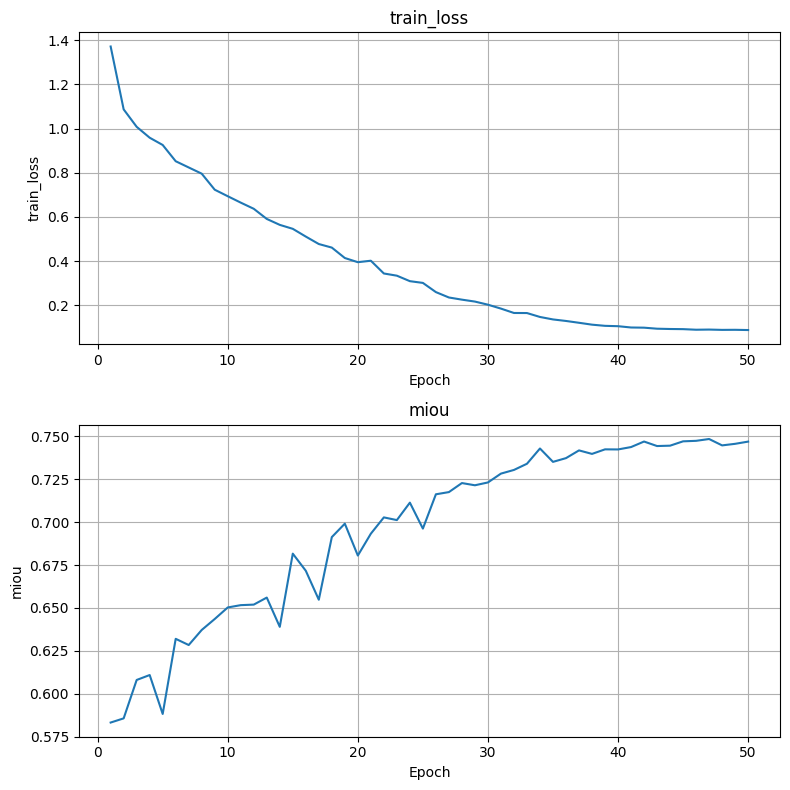

TypeError: Object of type Tensor is not JSON serializable

In [ ]:
from utils.plots import plot_training_metrics
from models.unet import UNet

teacher = UNet(num_classes=21, pretrained=True).to(device)
optimizer = optim.SGD(teacher.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)
optimizer = optim.Adam(teacher.parameters(), lr=0.0005, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
teacher_path = '../models/weights/voc_unet_teacher.pth'

metrics_teacher = train_val(train_loader, val_loader, teacher, optimizer, scheduler, device, teacher_path, epochs=50)
for i in range(len(metrics_teacher['miou'])):
    metrics_teacher['miou'][i] = metrics_teacher['miou'][i].item()
plot_training_metrics(metrics_teacher)
with open(os.path.join(project_dir, 'data/states/voc_unet_teacher.json'), 'w') as f:
    json.dump(metrics_teacher, f)

# Distill

In [ ]:
def distillation_loss(student_logits, teacher_logits, labels, T=2.0, alpha=0.5):
    """
    Compute the knowledge distillation loss.
    
    Args:
        student_logits: Logits from the student model
        teacher_logits: Logits from the teacher model
        labels: True labels
        T: Temperature for softening probability distributions
        alpha: Weight for the distillation loss vs. standard cross-entropy loss
    
    Returns:
        Combined loss
    """
    soft_targets = F.softmax(teacher_logits / T, dim=1)
    soft_prob = F.log_softmax(student_logits / T, dim=1)
    distillation = F.kl_div(soft_prob, soft_targets, reduction='batchmean') * (T * T)
    standard_loss = F.cross_entropy(student_logits, labels)
    return alpha * distillation + (1 - alpha) * standard_loss


def train_with_distillation(student_model, teacher_model, train_loader, optimizer, device, alpha=0.5, temperature=2.0):
    student_model.train()
    teacher_model.eval()  # Teacher is fixed during distillation
    
    total_loss = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.squeeze(1).long().to(device)
        
        optimizer.zero_grad()
        
        # Forward pass with student
        student_output = student_model(data)
        
        # Get teacher predictions (no grad needed)
        with torch.no_grad():
            teacher_output = teacher_model(data)
        
        # Calculate distillation loss
        loss = distillation_loss(
            student_output, 
            teacher_output, 
            target, 
            T=temperature,
            alpha=alpha, 
        )
        
        # Backward and optimize
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


In [ ]:
from models.unet import TeacherUNet
from models.unet import StudentUNet

# criterion = nn.CrossEntropyLoss(ignore_index=255)
teacher = TeacherUNet(in_channels=3, num_classes=21).to(device)
student = StudentUNet(in_channels=3, num_classes=21).to(device)
teacher.load_state_dict(torch.load('../models/weights/teacher_seg.pth', map_location=device)['state_dict'])
criterion = MIoU(20)
# optimizer = optim.SGD(student.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
optimizer = torch.optim.Adam(student.parameters(), lr=0.001)
scheduler = StepLR(optimizer, step_size=30, gamma=0.1)
student_path = f'../models/weights/student_seg.pth'

metrics = {'train_loss': [], 'MIoU': []}

for epoch in range(100):
    train_loss = train_with_distillation(
        student, 
        teacher, 
        train_loader, 
        optimizer, 
        device,
        alpha=0.5, 
        temperature=2.0
    )
    val_loss = evaluate_model(val_loader, student, criterion, device)
    metrics['train_loss'].append(np.mean(train_loss))
    metrics['MIoU'].append(np.mean(val_loss))